# tICA distances 3 state

In [ ]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

Prepare data

In [32]:
trajectories_labels = ["tica_distances"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


In [3]:
MSM_LAG_NS = 200
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 30
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj


name = trajectories_labels[0]

data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
dtraj = data["traj"].copy()
centers = data["centers"].copy()
C = tce.fit(dtraj).fetch_model()
submodel = C.submodel_largest(directed=True)
print(f"Submodel for {name} has {submodel.n_states} microstates.")
micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)
if np.any(dtrajs_dict[name] == -1):
    print(f"Warning: {name} has unassigned microstates after cleaning.")
msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
msm_dict[name] = msm

MSM lag time in frames: 1000
Submodel for tica_distances has 30 microstates.


In [4]:
n_common = 3

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 3
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Define "core" and "transition-like" microstates. Check populations and transition matrix entries

In [40]:
# --------------------------------
# Define masks for each macrostate

core_threshold = 0.9



s0_mask = np.nonzero(pcca_memberships_dict["tica_distances"][:, 0] >= core_threshold)
s1_mask = np.nonzero(pcca_memberships_dict["tica_distances"][:, 1] >= core_threshold)
s2_mask = np.nonzero(pcca_memberships_dict["tica_distances"][:, 2] >= core_threshold)


ambiguous_mask = np.nonzero(
    (pcca_memberships_dict["tica_distances"][:, 0] < core_threshold) &
    (pcca_memberships_dict["tica_distances"][:, 1] < core_threshold) &
    (pcca_memberships_dict["tica_distances"][:, 2] < core_threshold)
) 

print("Macrostate 0 (?) has", len(s0_mask[0]), "microstates.")
print("Macrostate 1 (unfolded) has", len(s1_mask[0]), "microstates.")
print("Macrostate 2 (folded) has", len(s2_mask[0]), "microstates.")
print("Ambiguous microstates have", len(ambiguous_mask[0]), "microstates.")

Macrostate 0 (?) has 1 microstates.
Macrostate 1 (unfolded) has 7 microstates.
Macrostate 2 (folded) has 5 microstates.
Ambiguous microstates have 17 microstates.


<BarContainer object of 4 artists>

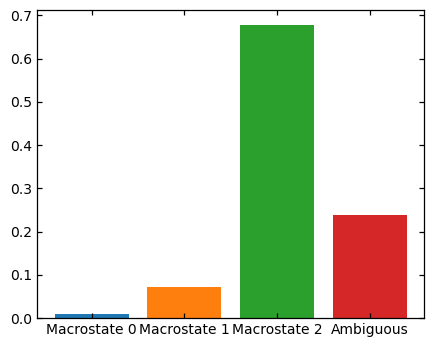

In [41]:
s0_pop = msm_dict["tica_distances"].stationary_distribution[s0_mask]
s1_pop = msm_dict["tica_distances"].stationary_distribution[s1_mask]
s2_pop = msm_dict["tica_distances"].stationary_distribution[s2_mask]
ambiguous_pop = msm_dict["tica_distances"].stationary_distribution[ambiguous_mask]




fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["Macrostate 0", "Macrostate 1", "Macrostate 2", "Ambiguous"],
    [s0_pop.sum(), s1_pop.sum(), s2_pop.sum(), ambiguous_pop.sum()],
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)

Compute core frames

In [42]:
s0_frames = np.nonzero(np.isin(dtrajs_dict["tica_distances"], s0_mask))[0]
s1_frames = np.nonzero(np.isin(dtrajs_dict["tica_distances"], s1_mask))[0]
s2_frames = np.nonzero(np.isin(dtrajs_dict["tica_distances"], s2_mask))[0]

print("Macrostate 0 (?) has", len(s0_frames), "core frames.")
print("Macrostate 1 (?) has", len(s1_frames), "core frames.")
print("Macrostate 2 (?) has", len(s2_frames), "core frames.")

Macrostate 0 (?) has 15883 core frames.
Macrostate 1 (?) has 114033 core frames.
Macrostate 2 (?) has 1025449 core frames.


Compute all frame assignments (hard and soft)

In [107]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]

    # shape: n_frames x n_macrostates
    p_macro = memberships[dtraj, :]

    # hard macrostate assignment
    hard = np.argmax(p_macro, axis=1)

    pcca_probabilities_timeseries_dict[name] = p_macro
    hard_assignments_timeseries_dict[name] = hard

    print(name)
    print("p_macro shape:", p_macro.shape)
    print("hard shape:", hard.shape)
    print("macrostate counts:", np.bincount(hard))
    print()

tica_distances
p_macro shape: (1526041, 3)
hard shape: (1526041,)
macrostate counts: [  15883  475514 1034644]



---

## Structural Analysis

### Helicity

In [43]:

# --------------------------------
# Helix dict
# --------------------------------
helices = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

contact_names = np.loadtxt(
    data_folder + "hp35.crystaldists.ndx",
    delimiter=" ",
    dtype=int
)

print("Contact names shape:", contact_names.shape)

# Make sure contact_names is shaped as (n_contacts, 2)
if contact_names.ndim == 1:
    contact_names = contact_names.reshape(-1, 2)

contact_lookup = {i: tuple(contact_names[i]) for i in range(contact_names.shape[0])}

print("First contacts:")
for i in range(min(10, len(contact_lookup))):
    print(i, contact_lookup[i])


# --------------------------------
# Find contacts internal to helices
# --------------------------------

def find_contacts_within_region(contact_names, start, end):
    """
    Return indices of contacts whose two residues both lie in [start, end].

    Assumes contact_names has shape (n_contacts, 2), with residue numbering
    consistent with the helix definitions.
    """
    indices = []

    for k, (res_i, res_j) in enumerate(contact_names):
        if start <= res_i <= end and start <= res_j <= end:
            indices.append(k)

    return np.array(indices, dtype=int)


helix_contact_indices = {}

for helix_name, (start, end) in helices.items():
    idx = find_contacts_within_region(contact_names, start, end)
    helix_contact_indices[helix_name] = idx

    print(f"\n{helix_name}: residues {start}-{end}")
    print(f"Number of internal contacts: {len(idx)}")

    for k in idx:
        print(f"  column {k}: contact {tuple(contact_names[k])}")

Contact names shape: (53, 2)
First contacts:
0 (1, 5)
1 (1, 6)
2 (1, 9)
3 (1, 10)
4 (1, 14)
5 (1, 34)
6 (2, 6)
7 (3, 7)
8 (3, 14)
9 (4, 8)

H1: residues 3-10
Number of internal contacts: 4
  column 7: contact (3, 7)
  column 9: contact (4, 8)
  column 10: contact (5, 9)
  column 11: contact (6, 10)

H2: residues 14-19
Number of internal contacts: 2
  column 32: contact (14, 18)
  column 33: contact (15, 19)

H3: residues 22-32
Number of internal contacts: 7
  column 43: contact (22, 26)
  column 44: contact (23, 27)
  column 45: contact (24, 28)
  column 46: contact (25, 29)
  column 47: contact (26, 30)
  column 48: contact (27, 31)
  column 49: contact (28, 32)


In [90]:
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm



helix_distances_reference = {}
for helix_name, idx in helix_contact_indices.items():
    helix_distances_reference[helix_name] = [reference_distances[i+1, i + 5] for i in range(len(idx))]
    print(f"{helix_name} reference distances:", helix_distances_reference[helix_name])

H1 reference distances: [0.2823720932006836, 0.30382633209228516, 0.3010305881500244, 0.2969738721847534]
H2 reference distances: [0.2823720932006836, 0.30382633209228516]
H3 reference distances: [0.2823720932006836, 0.30382633209228516, 0.3010305881500244, 0.2969738721847534, 0.2920261383056641, 0.27554872035980227, 0.5627542972564697]


In [ ]:
helix_distances_s0 = {}
helix_distances_s1 = {}
helix_distances_s2 = {}
for helix_name, idx in helix_contact_indices.items():
    helix_distances_s0[helix_name] = crystal_dist[s0_frames][idx]
    helix_distances_s1[helix_name] = crystal_dist[s1_frames][idx]
    helix_distances_s2[helix_name] = crystal_dist[s2_frames][idx]





def build_contact_distance_dataframe(helix_distances_dict, basin_name):
    rows = []

    for helix_name, distances in helix_distances_dict.items():
        contact_ids = helix_contact_indices[helix_name]

        for local_i, contact_id in enumerate(contact_ids):
            start_res, end_res = contact_lookup[contact_id]

            values = distances[:, local_i]

            for v in values:
                rows.append({
                    "Helix": helix_name,
                    "Contact ID": contact_id,
                    "Start residue": start_res + 1,   # change if already 1-based
                    "End residue": end_res + 1,
                    "Contact label": f"{start_res + 1}-{end_res + 1}",
                    "Distance": v,
                    "Basin": basin_name
                })

    return pd.DataFrame(rows)


df_s0 = build_contact_distance_dataframe(
    helix_distances_s0,
    "S0"
)

df_s1 = build_contact_distance_dataframe(
    helix_distances_s1,
    "S1"
)

df_s2 = build_contact_distance_dataframe(
    helix_distances_s2,
    "S2"
)

df_contacts = pd.concat([df_s0, df_s1, df_s2], ignore_index=True)

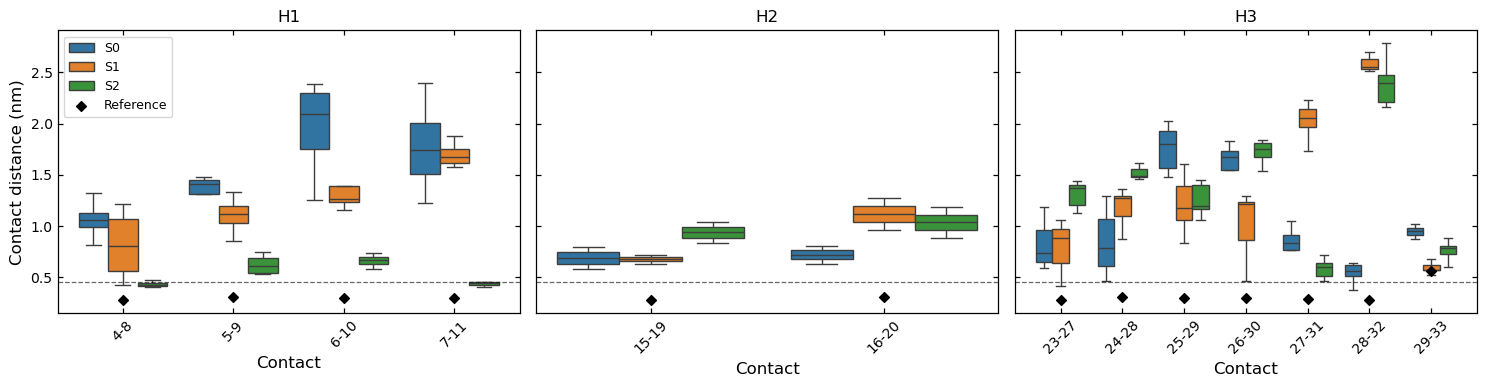

In [93]:
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm

contact_cutoff = 0.45  # nm

fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharey=True
)

for ax, helix_name in zip(axs, ["H1", "H2", "H3"]):

    sub = df_contacts[df_contacts["Helix"] == helix_name].copy()

    # Keep contact order fixed
    contact_order = sub["Contact label"].drop_duplicates().tolist()

    sns.boxplot(
        data=sub,
        x="Contact label",
        y="Distance",
        hue="Basin",
        order=contact_order,
        showfliers=False,
        ax=ax
    )

    # Reference distances
    ref_x = []
    ref_y = []
    

    for i, contact_id in enumerate(helix_contact_indices[helix_name]):
        start_res, end_res = contact_lookup[contact_id]

        # If contact_lookup is 0-based
        contact_label = f"{start_res + 1}-{end_res + 1}"
        ref_distance = helix_distances_reference[helix_name][i]

        # Skip contacts that are not in the dataframe
        if contact_label not in contact_order:
            continue

        x_pos = contact_order.index(contact_label)

        ref_x.append(x_pos)
        ref_y.append(ref_distance)

    ax.scatter(
        ref_x,
        ref_y,
        color="black",
        marker="D",
        s=25,
        zorder=10,
        label="Reference"
    )

    ax.axhline(
        contact_cutoff,
        color="black",
        linestyle="--",
        linewidth=0.9,
        alpha=0.6
    )

    ax.set_title(helix_name)
    ax.set_xlabel("Contact")
    ax.set_ylabel("Contact distance (nm)")
    ax.tick_params(axis="x", rotation=45)

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()

    if helix_name == "H1":
        # Remove duplicate labels while preserving order
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), title="", loc="upper left")
    else:
        ax.get_legend().remove()

plt.tight_layout()



plt.savefig("../output_figures/threestate_tica_helix_differences.pdf", bbox_inches="tight")
plt.savefig("../output_figures/threestate_tica_helix_differences.png", dpi=600, bbox_inches="tight")

### Contact maps

Complete contact maps, compared in the three macrostates

In [78]:
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

n_res = 35
min_seq_sep = 4
cutoff = 0.45  # nm

helix_ranges = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

In [79]:
def apply_sequence_separation_mask(contact_map, min_seq_sep=4):
    contact_map = contact_map.copy()

    n_res = contact_map.shape[0]

    for i in range(n_res):
        for j in range(n_res):
            if abs(i - j) < min_seq_sep:
                contact_map[i, j] = np.nan

    return contact_map


def decorate_contact_map(ax, n_res=35, helix_ranges=None):
    if helix_ranges is None:
        helix_ranges = {
            "H1": (3, 10),
            "H2": (14, 19),
            "H3": (22, 32),
        }

    # Grid
    ax.set_xticks(np.arange(-0.5, n_res, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_res, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.25, alpha=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Same-helix blocks
    for hname, (start, end) in helix_ranges.items():
        width = end - start + 1

        rect = Rectangle(
            (start - 1 - 0.5, start - 1 - 0.5),
            width,
            width,
            fill=False,
            linestyle="-",
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

        ax.text(
            (start + end) / 2 - 1,
            start - 2.0,
            hname,
            ha="center",
            va="center",
            fontsize=8,
            zorder=5
        )

    # Inter-helix blocks
    helix_items = list(helix_ranges.items())

    for idx_a, (h1, (s1, e1)) in enumerate(helix_items):
        for idx_b, (h2, (s2, e2)) in enumerate(helix_items):
            if idx_b <= idx_a:
                continue

            s1i, e1i = s1 - 1, e1 - 1
            s2i, e2i = s2 - 1, e2 - 1

            w1 = e1i - s1i + 1
            w2 = e2i - s2i + 1

            rect1 = Rectangle(
                (s1i - 0.5, s2i - 0.5),
                w1,
                w2,
                fill=False,
                linestyle="--",
                linewidth=1.1,
                zorder=4
            )

            rect2 = Rectangle(
                (s2i - 0.5, s1i - 0.5),
                w2,
                w1,
                fill=False,
                linestyle="--",
                linewidth=1.1,
                zorder=4
            )

            ax.add_patch(rect1)
            ax.add_patch(rect2)

            ax.text(
                (s1i + e1i) / 2,
                (s2i + e2i) / 2,
                f"{h1}-{h2}",
                ha="center",
                va="center",
                fontsize=7,
                alpha=0.75,
                zorder=5
            )

    # Axis formatting
    ax.set_xlim(-0.5, n_res - 0.5)
    ax.set_ylim(-0.5, n_res - 0.5)
    ax.set_aspect("equal")

    major_ticks = np.arange(0, n_res, 5)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    # Show residue labels as 1-based
    ax.set_xticklabels(major_ticks + 1)
    ax.set_yticklabels(major_ticks + 1)

    ax.set_xlabel("Residue index")
    ax.set_ylabel("Residue index")

In [80]:
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm

reference_distances = apply_sequence_separation_mask(
    reference_distances,
    min_seq_sep=min_seq_sep
)

In [81]:
def compute_median_distance_map(frames, crystal_dist, contact_names, min_seq_sep=4, n_res=35):
    selected_distances = crystal_dist[frames]

    median_distances = np.nanmedian(selected_distances, axis=0)

    distance_map = np.full((n_res, n_res), np.nan)

    for k, (res_i, res_j) in enumerate(contact_names):
        i = res_i - 1
        j = res_j - 1

        if abs(i - j) < min_seq_sep:
            continue

        distance_map[i, j] = median_distances[k]
        distance_map[j, i] = median_distances[k]

    return distance_map

In [83]:
macro_distance_maps = {
    "S0": compute_median_distance_map(s0_frames, crystal_dist, contact_names, min_seq_sep=min_seq_sep),
    "S1": compute_median_distance_map(s1_frames, crystal_dist, contact_names, min_seq_sep=min_seq_sep),
    "S2": compute_median_distance_map(s2_frames, crystal_dist, contact_names, min_seq_sep=min_seq_sep),
}


reference_distance_map = reference_distances.copy()

delta_distance_maps = {}

for name, distance_map in macro_distance_maps.items():
    delta_distance_maps[f"{name} - reference"] = distance_map - reference_distance_map

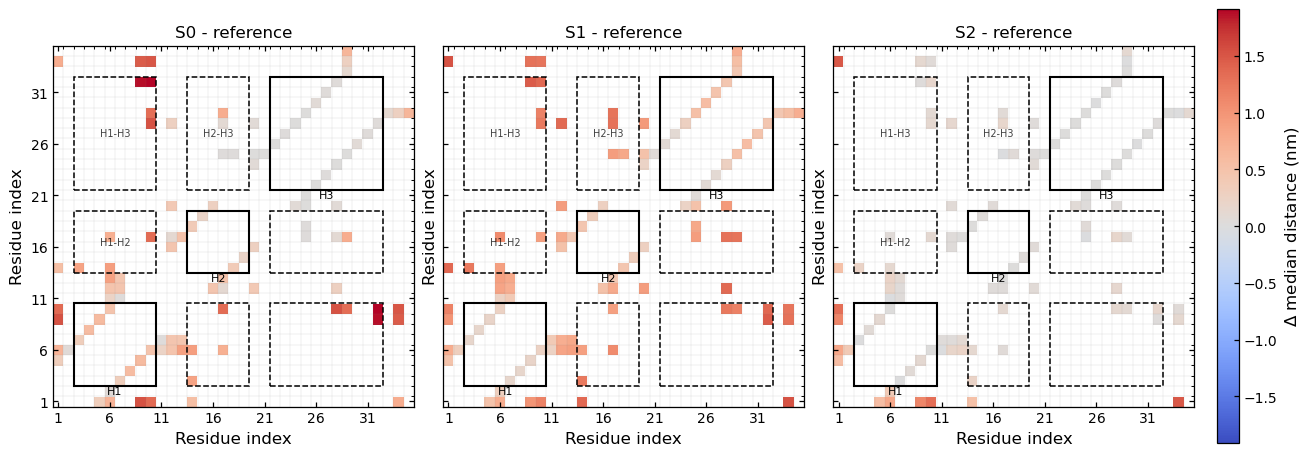

In [86]:
global_vmax = np.nanmax([
    np.nanmax(np.abs(delta_map))
    for delta_map in delta_distance_maps.values()
])

fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, (title, delta_map) in zip(axs, delta_distance_maps.items()):
    norm = TwoSlopeNorm(vmin=-global_vmax, vcenter=0.0, vmax=global_vmax)

    im = ax.imshow(
        delta_map,
        origin="lower",
        cmap="coolwarm",
        norm=norm
    )

    ax.set_title(title)
    decorate_contact_map(ax, n_res=n_res, helix_ranges=helix_ranges)

fig.colorbar(
    im,
    ax=axs,
    fraction=0.025,
    pad=0.02,
    label=r"$\Delta$ median distance (nm)"
)

plt.show()

---
# Representative frames ensemble